# Projeto de Data Science — Jogadores de Futebol
## Notebook 01 — Limpeza e Preparação dos Dados

### Origem dos dados
Utilizei o FIFA 22 complete player dataset, com atributos de todos os
jogadores do videogame EA SPORTS FIFA 22. Os dados foram raspados do site
[sofifa.com](https://sofifa.com) que, conforme o próprio `robots.txt`, não
impõe restrições à coleta de dados de jogadores. Cada linha representa um
jogador e contém dados pessoais (idade, nacionalidade, clube, liga), o valor de
mercado, o salário e cerca de 40 atributos técnicos avaliados de 0 a 100.

### Problema que o projeto busca resolver
Atuando como uma área de análise de um clube/empresário, queremos responder:
1. **Quais fatores determinam o valor de mercado de um jogador?**
2. **É possível prever esse valor a partir dos atributos? Qual modelo erra menos: Regressão Linear ou KNN?**
3. **Os atributos técnicos agrupam os jogadores em perfis que correspondem às posições reais em campo?** (K-Means)


## 1. Importação das bibliotecas

In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de exibição e estilo dos gráficos
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42  # semente para reprodutibilidade

## 2. Coleta / Importação dos dados

A célula abaixo deixa o notebook **reprodutível**: se o arquivo bruto ainda não
estiver na pasta `data/`, ele é baixado automaticamente da cópia pública
hospedada no GitHub.

In [2]:
DATA_DIR = "../data"
RAW_PATH = os.path.join(DATA_DIR, "players_22.csv")
RAW_URL = ("https://raw.githubusercontent.com/abineshta/"
           "FIFA-22-complete-player-dataset-EDA/main/players_22.csv")

os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(RAW_PATH):
    print("Arquivo não encontrado localmente. Baixando do GitHub...")
    urllib.request.urlretrieve(RAW_URL, RAW_PATH)
    print("Download concluído.")

df_raw = pd.read_csv(RAW_PATH, low_memory=False)
print(f"Dimensões do dataset bruto: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")
df_raw.head(3)

Dimensões do dataset bruto: 19,239 linhas x 110 colunas


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined,club_contract_valid_until,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,"78,000,000.00","320,000.00",34,1987-06-24,170,72,73.00,Paris Saint-Germain,French Ligue 1,1.00,RW,30.00,NaN,2021-08-10,"2,023.00",52,Argentina,"1,369.00",RW,10.00,Left,4,4,5,Medium/Low,Unique,Yes,"144,300,000.00","#Dribbler, #Distance Shooter, #FK Specialist, ...","Finesse Shot, Long Shot Taker (AI), Playmaker ...",85.00,92.00,91.00,95.00,34.00,65.00,85,95,70,91,88,96,93,94,91,96,91,80,91,94,95,86,68,72,69,94,44,40,93,95,75,96,20,35,24,6,11,15,14,8,NaN,89+3,89+3,89+3,92,93,93,93,92,93,93,93,91+2,87+3,87+3,87+3,91+2,66+3,64+3,64+3,64+3,66+3,61+3,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,"119,500,000.00","270,000.00",32,1988-08-21,185,81,21.00,FC Bayern München,German 1. Bundesliga,1.00,ST,9.00,NaN,2014-07-01,"2,023.00",37,Poland,"1,353.00",RS,9.00,Right,4,4,5,High/Medium,Unique,Yes,"197,200,000.00","#Aerial Threat, #Distance Shooter, #Clinical F...","Solid Player, Finesse Shot, Outside Foot Shot,...",78.00,92.00,79.00,86.00,44.00,82.00,71,95,90,85,89,85,79,85,70,88,77,79,77,93,82,90,85,76,86,87,81,49,95,81,90,88,35,42,19,15,6,12,8,10,NaN,90+2,90+2,90+2,85,88,88,88,85,86+3,86+3,86+3,84+3,80+3,80+3,80+3,84+3,64+3,66+3,66+3,66+3,64+3,61+3,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,"45,000,000.00","270,000.00",36,1985-02-05,187,83,11.00,Manchester United,English Premier League,1.00,ST,7.00,NaN,2021-08-27,"2,023.00",38,Portugal,"1,354.00",ST,7.00,Right,4,5,5,High/Low,Unique,Yes,"83,300,000.00","#Aerial Threat, #Dribbler, #Distance Shooter, ...","Power Free-Kick, Flair, Long Shot Taker (AI), ...",87.00,94.00,80.00,88.00,34.00,75.00,87,95,90,80,86,88,81,84,77,88,85,88,86,94,74,94,95,77,77,93,63,29,95,76,88,95,24,32,24,7,11,15,14,11,NaN,90+1,90+1,90+1,88,89,89,89,88,86+3,86+3,86+3,86+3,78+3,78+3,78+3,86+3,63+3,59+3,59+3,59+3,63+3,60+3,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.ne

## 3. Inspeção inicial

Antes de qualquer transformação, precisamos entender a estrutura dos dados:
quantas colunas existem, seus tipos e — principalmente — onde estão os
**valores ausentes**.

In [3]:
# Visão geral dos tipos de dados
print("Tipos de dados:")
print(df_raw.dtypes.value_counts())
print(f"\nTotal de colunas: {df_raw.shape[1]}")

Tipos de dados:
str        50
int64      44
float64    16
Name: count, dtype: int64

Total de colunas: 110


In [4]:
# Percentual de valores ausentes por coluna (apenas colunas com algum ausente)
ausentes = (df_raw.isna().mean() * 100).sort_values(ascending=False)
ausentes = ausentes[ausentes > 0]
print(f"{len(ausentes)} colunas possuem valores ausentes.\n")
print(ausentes.head(20).round(1))

27 colunas possuem valores ausentes.

nation_jersey_number   96.10
nation_team_id         96.10
nation_position        96.10
nation_logo_url        96.10
club_loaned_from       94.30
player_tags            92.50
goalkeeping_speed      88.90
player_traits          51.20
pace                   11.10
physic                 11.10
defending              11.10
dribbling              11.10
passing                11.10
shooting               11.10
release_clause_eur      6.10
club_joined             6.00
value_eur               0.40
league_name             0.30
wage_eur                0.30
league_level            0.30
dtype: float64


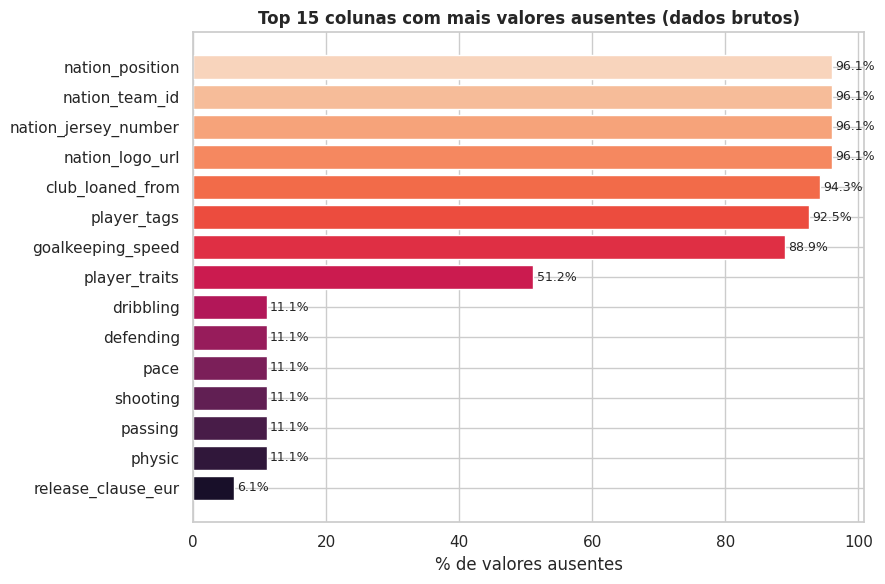

In [5]:
# Gráfico das colunas com maior proporção de ausentes
fig, ax = plt.subplots(figsize=(9, 6))
top_aus = ausentes.head(15).sort_values()
ax.barh(top_aus.index, top_aus.values, color=sns.color_palette("rocket", len(top_aus)))
ax.set_xlabel("% de valores ausentes")
ax.set_title("Top 15 colunas com mais valores ausentes (dados brutos)")
for i, v in enumerate(top_aus.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Leitura do gráfico — os ausentes não são aleatórios:**

- As colunas de **seleção nacional** (`nation_*`) faltam para ~96% dos jogadores,
  porque a maioria não é convocada para suas seleções.
- `club_loaned_from` falta para ~94% — só jogadores emprestados têm essa informação.
- `goalkeeping_speed` falta para ~89% — atributo que praticamente não é preenchido.
- Os **6 atributos agregados** (`pace`, `shooting`, `passing`, `dribbling`,
  `defending`, `physic`) faltam para **exatamente ~11%** dos jogadores. Esse número
  não é coincidência: corresponde aos **goleiros**, que não possuem esses atributos
  de jogador de linha. Voltaremos a esse ponto na etapa de limpeza.

## 4. Seleção de colunas

O dataset bruto tem 110 colunas, muitas das quais não são úteis para o nosso
problema. Vamos **selecionar um subconjunto** com justificativa:

- **Descartamos** identificadores e URLs (`player_url`, `*_url`), dados de
  seleção e empréstimo (quase vazios), colunas de tags/traits (texto livre e
  esparso) e as 27 colunas de *rating por posição* (`ls`, `st`, ... `gk`), que
  vêm em formato textual confuso (ex.: `"85+2"`).
- **Descartamos `release_clause_eur`** (cláusula de rescisão): ela é praticamente
  uma função direta do valor de mercado e, se usada na modelagem, causaria
  **vazamento de dados** (*data leakage*).
- **Mantemos** identificação básica, valor/salário, perfil físico, posição e os
  **35 atributos técnicos** (6 agregados + 29 detalhados), que são o coração da
  análise.

In [6]:
colunas_id = ["sofifa_id", "short_name", "long_name",
              "club_name", "league_name", "league_level", "nationality_name"]

colunas_alvo = ["value_eur", "wage_eur"]

colunas_perfil = ["age", "height_cm", "weight_kg", "preferred_foot",
                  "weak_foot", "skill_moves", "international_reputation",
                  "work_rate", "overall", "potential", "player_positions"]

atributos_agregados = ["pace", "shooting", "passing", "dribbling",
                       "defending", "physic"]

atributos_detalhados = [
    "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy",
    "attacking_short_passing", "attacking_volleys",
    "skill_dribbling", "skill_curve", "skill_fk_accuracy",
    "skill_long_passing", "skill_ball_control",
    "movement_acceleration", "movement_sprint_speed", "movement_agility",
    "movement_reactions", "movement_balance",
    "power_shot_power", "power_jumping", "power_stamina",
    "power_strength", "power_long_shots",
    "mentality_aggression", "mentality_interceptions", "mentality_positioning",
    "mentality_vision", "mentality_penalties", "mentality_composure",
    "defending_marking_awareness", "defending_standing_tackle",
    "defending_sliding_tackle",
]

colunas_mantidas = (colunas_id + colunas_alvo + colunas_perfil
                    + atributos_agregados + atributos_detalhados)

df = df_raw[colunas_mantidas].copy()
print(f"Colunas após seleção: {df.shape[1]} (de {df_raw.shape[1]} originais)")
print(f"  - {len(atributos_agregados)} atributos agregados")
print(f"  - {len(atributos_detalhados)} atributos detalhados")

Colunas após seleção: 55 (de 110 originais)
  - 6 atributos agregados
  - 29 atributos detalhados


## 5. Tratamento de valores ausentes

### 5.1. Linhas sem o alvo
O valor de mercado (`value_eur`) é a variável que queremos prever. Linhas sem
esse valor não servem para treinar nem avaliar o modelo, então são removidas.

In [7]:
n_antes = len(df)
df = df.dropna(subset=["value_eur"]).copy()
print(f"Removidas {n_antes - len(df)} linhas sem valor de mercado. Restam {len(df):,}.")

Removidas 74 linhas sem valor de mercado. Restam 19,165.


### 5.2. Separação dos goleiros
Como vimos, os goleiros não possuem os atributos de jogador de linha (pace,
shooting, etc.). Como o foco do projeto é **valor e perfil de jogadores de
linha** — e como goleiros formariam, na clusterização, um grupo trivialmente
separado por terem todos os atributos ausentes — vamos **separar os goleiros** e
seguir a análise apenas com jogadores de linha. Registramos quantos goleiros
foram retirados, para documentação.

In [8]:
# A posição principal é a primeira listada em player_positions
df["pos_principal"] = df["player_positions"].str.split(",").str[0].str.strip()

eh_goleiro = df["pos_principal"] == "GK"
print(f"Goleiros identificados: {eh_goleiro.sum():,}")
print(f"Jogadores de linha:    {(~eh_goleiro).sum():,}")

df = df[~eh_goleiro].copy()
# Atributos de goleiro não se aplicam aqui — não foram sequer mantidos na seleção.

Goleiros identificados: 2,124
Jogadores de linha:    17,041


### 5.3. Ausentes residuais
Após remover os goleiros, os atributos de linha devem estar praticamente
completos. Verificamos o que sobrou e imputamos eventuais ausentes residuais
pela **mediana** (robusta a valores extremos).

In [9]:
ausentes_resid = df.isna().sum()
ausentes_resid = ausentes_resid[ausentes_resid > 0]
print("Ausentes residuais por coluna:")
print(ausentes_resid if len(ausentes_resid) else "Nenhum atributo numérico com ausentes.")

# Imputação pela mediana nos atributos numéricos (caso haja resíduo)
cols_num_attr = atributos_agregados + atributos_detalhados
for c in cols_num_attr:
    if df[c].isna().any():
        mediana = df[c].median()
        df[c] = df[c].fillna(mediana)

# league_level pode ter poucos ausentes — preenchemos com o nível mais comum
if df["league_level"].isna().any():
    df["league_level"] = df["league_level"].fillna(df["league_level"].mode()[0])

print("\nAusentes após imputação:", int(df[cols_num_attr].isna().sum().sum()))

Ausentes residuais por coluna:
Nenhum atributo numérico com ausentes.

Ausentes após imputação: 0


## 6. Engenharia de features

Criamos novas variáveis que enriquecem a análise:

- **`field_sector`** — agrupa as ~15 posições em 4 setores de campo (aqui, 3, já
  que goleiros foram removidos): Defensor, Meio-campo e Atacante. Simplifica a EDA
  e serve de "gabarito" para comparar com os clusters do K-Means.
- **`potential_gap`** — diferença entre potencial e overall (margem de evolução).
- **`bmi`** — índice de massa corporal, a partir de altura e peso.
- **`value_log` / `wage_log`** — transformação logarítmica do valor e do salário
  (justificada na próxima seção pela forte assimetria).

In [10]:
# Mapeamento posição -> setor de campo
mapa_setor = {
    # Defensores
    "CB": "Defensor", "LB": "Defensor", "RB": "Defensor",
    "LWB": "Defensor", "RWB": "Defensor",
    # Meio-campo
    "CDM": "Meio-campo", "CM": "Meio-campo", "CAM": "Meio-campo",
    "RM": "Meio-campo", "LM": "Meio-campo",
    # Atacantes
    "ST": "Atacante", "CF": "Atacante", "RW": "Atacante",
    "LW": "Atacante", "RF": "Atacante", "LF": "Atacante",
}
df["field_sector"] = df["pos_principal"].map(mapa_setor)

# Verificação: nenhuma posição de linha pode ficar sem setor
sem_setor = df["field_sector"].isna().sum()
print(f"Jogadores sem setor mapeado: {sem_setor}")
assert sem_setor == 0, "Há posições não mapeadas — revisar o dicionário."

# Demais features
df["potential_gap"] = df["potential"] - df["overall"]
df["bmi"] = df["weight_kg"] / (df["height_cm"] / 100) ** 2
df["value_log"] = np.log1p(df["value_eur"])
df["wage_log"] = np.log1p(df["wage_eur"])

print("\nDistribuição por setor de campo:")
print(df["field_sector"].value_counts())

Jogadores sem setor mapeado: 0

Distribuição por setor de campo:
field_sector
Meio-campo    7009
Defensor      6366
Atacante      3666
Name: count, dtype: int64


## 7. Análise de outliers e a transformação logarítmica

O valor de mercado é uma variável extremamente **assimétrica à direita**: há
milhares de jogadores comuns e uma minoria de superestrelas que valem centenas
de milhões. Esses valores altos são **reais** (não são erros de digitação), então
não devem ser removidos. A solução padrão é aplicar a **transformação
logarítmica**, que comprime a cauda e aproxima a distribuição de uma normal —
beneficiando tanto a visualização quanto modelos lineares.

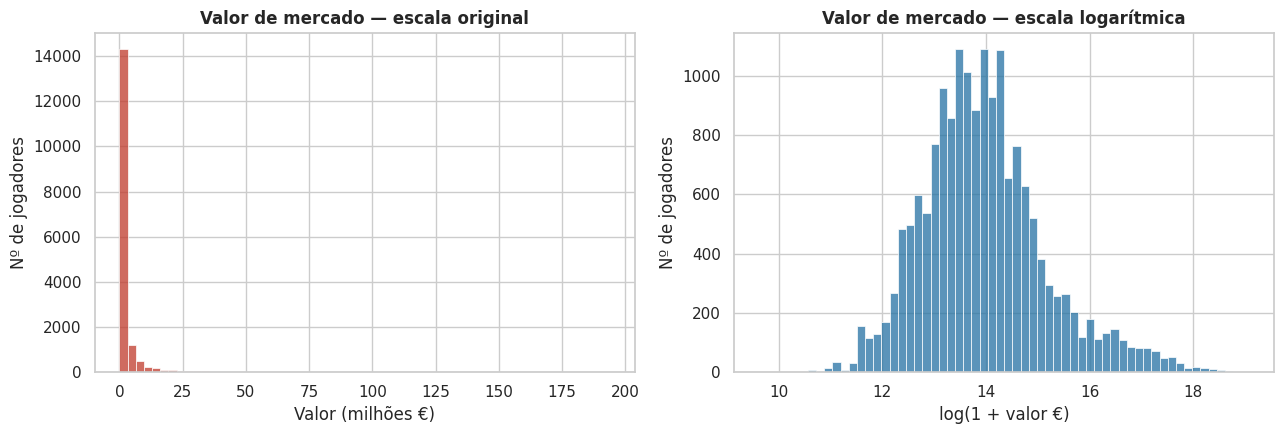

Assimetria (skewness) original: 7.99
Assimetria após log:           0.67


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["value_eur"] / 1e6, bins=60, ax=axes[0], color="#c0392b")
axes[0].set_title("Valor de mercado — escala original")
axes[0].set_xlabel("Valor (milhões €)")
axes[0].set_ylabel("Nº de jogadores")

sns.histplot(df["value_log"], bins=60, ax=axes[1], color="#2471a3")
axes[1].set_title("Valor de mercado — escala logarítmica")
axes[1].set_xlabel("log(1 + valor €)")
axes[1].set_ylabel("Nº de jogadores")

plt.tight_layout()
plt.show()

print(f"Assimetria (skewness) original: {df['value_eur'].skew():.2f}")
print(f"Assimetria após log:           {df['value_log'].skew():.2f}")

A assimetria cai drasticamente após o log, confirmando que essa será a forma
adequada de tratar o alvo na modelagem (a **Hipótese H1** — relação exponencial
entre qualidade e valor — começa a se confirmar).

## 8. Verificação final e exportação

Conferimos as dimensões finais, garantimos que não há ausentes e salvamos o
dataset limpo em `data/players_clean.csv`.

In [12]:
print(f"Dimensões finais: {df.shape[0]:,} jogadores x {df.shape[1]} colunas")
print(f"Total de valores ausentes: {int(df.isna().sum().sum())}")
print(f"Linhas duplicadas: {int(df.duplicated(subset='sofifa_id').sum())}")

df.head(3)

Dimensões finais: 17,041 jogadores x 61 colunas
Total de valores ausentes: 0
Linhas duplicadas: 0


,sofifa_id,short_name,long_name,club_name,league_name,league_level,nationality_name,value_eur,wage_eur,age,height_cm,weight_kg,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,overall,potential,player_positions,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,pos_principal,field_sector,potential_gap,bmi,value_log,wage_log
0,158023,L. Messi,Lionel Andrés Messi Cuccittini,Paris Saint-Germain,French Ligue 1,1.00,Argentina,"78,000,000.00","320,000.00",34,170,72,Left,4,4,5,Medium/Low,93,93,"RW, ST, CF",85.00,92.00,91.00,95.00,34.00,65.00,85,95,70,91,88,96,93,94,91,96,91,80,91,94,95,86,68,72,69,94,44,40,93,95,75,96,20,35,24,RW,Atacante,0,24.91,18.17,12.68
1,188545,R. Lewandowski,Robert Lewandowski,FC Bayern München,German 1. Bundesliga,1.00,Poland,"119,500,000.00","270,000.00",32,185,81,Right,4,4,5,High/Medium,92,92,ST,78.00,92.00,79.00,86.00,44.00,82.00,71,95,90,85,89,85,79,85,70,88,77,79,77,93,82,90,85,76,86,87,81,49,95,81,90,88,35,42,19,ST,Atacante,0,23.67,18.60,12.51
2,20801,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,Manchester United,English Premier League,1.00,Portugal,"45,000,000.00","270,000.00",36,187,83,Right,4,5,5,High/Low,91,91,"ST, LW",87.00,94.00,80.00,88.00,34.00,75.00,87,95,90,80,86,88,81,84,77,88,85,88,86,94,74,94,95,77,77,93,63,29,95,76,88,95,24,32,24,ST,Atacante,0,23.74,17.62,12.51


In [13]:
CLEAN_PATH = os.path.join(DATA_DIR, "players_clean.csv")
df.to_csv(CLEAN_PATH, index=False)
print(f"Dataset limpo salvo em: {CLEAN_PATH}")
print(f"Tamanho: {os.path.getsize(CLEAN_PATH) / 1e6:.1f} MB")

Dataset limpo salvo em: ../data/players_clean.csv
Tamanho: 5.8 MB


## 9. Dicionário de variáveis (resumo)

Tabela com as principais variáveis do dataset limpo, para referência no relatório.

In [14]:
dicionario = pd.DataFrame([
    ("short_name", "Nome do jogador", "texto"),
    ("club_name / league_name", "Clube e liga", "categórica"),
    ("nationality_name", "Nacionalidade", "categórica"),
    ("value_eur", "Valor de mercado (alvo)", "numérica (€)"),
    ("wage_eur", "Salário semanal", "numérica (€)"),
    ("age / height_cm / weight_kg", "Perfil físico", "numérica"),
    ("overall / potential", "Nota geral e potencial (0-100)", "numérica"),
    ("player_positions / pos_principal", "Posições do jogador", "categórica"),
    ("field_sector", "Setor de campo (engenharia)", "categórica"),
    ("pace ... defending", "6 atributos agregados (0-100)", "numérica"),
    ("attacking_* ... mentality_*", "29 atributos detalhados (0-100)", "numérica"),
    ("potential_gap", "Potencial - Overall (engenharia)", "numérica"),
    ("bmi", "Índice de massa corporal (engenharia)", "numérica"),
    ("value_log / wage_log", "Log do valor e do salário (engenharia)", "numérica"),
], columns=["Variável", "Descrição", "Tipo"])
dicionario

,Variável,Descrição,Tipo
0,short_name,Nome do jogador,texto
1,club_name / league_name,Clube e liga,categórica
2,nationality_name,Nacionalidade,categórica
3,value_eur,Valor de mercado (alvo),numérica (€)
4,wage_eur,Salário semanal,numérica (€)
5,age / height_cm / weight_kg,Perfil físico,numérica
6,overall / potential,Nota geral e potencial (0-100),numérica
7,player_positions / pos_principal,Posições do jogador,categórica
8,field_sector,Setor de campo (engenharia),categórica
9,pace ... defending,6 atributos agregados (0-100),numérica


---
### Resumo do que foi feito neste notebook
1. Importamos o dataset bruto do FIFA 22 (19.239 jogadores, 110 colunas).
2. Selecionamos 55 colunas relevantes, descartando URLs, dados esparsos,
   ratings por posição e a cláusula de rescisão (para evitar *data leakage*).
3. Removemos linhas sem o alvo e **separamos os goleiros** (ausência estrutural
   de atributos de linha).
4. Imputamos ausentes residuais pela mediana.
5. Criamos as features `field_sector`, `potential_gap`, `bmi`, `value_log` e
   `wage_log`.
6. Justificamos e aplicamos a transformação logarítmica no valor.
7. Exportamos `players_clean.csv` para os próximos notebooks.

 **Próximo notebook:** `02_eda.ipynb` — Análise Exploratória de Dados.